<a href="https://colab.research.google.com/github/98Dinesh89/24117044Satellite-Imagery-Based-Property-Valuation/blob/main/CIR_Yield_Curve_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Interest Rate Modelling and Prediction
## Cox-Ingersoll-Ross Model: Implementation, Calibration, and Extension
### Finance Club, IIT Roorkee, Open Projects 2026

---

## Overview

This notebook implements a full pipeline for stochastic short-rate modelling using the **Cox-Ingersoll-Ross (CIR)** framework. The central challenge is:

> Given only the **3-Month yield** on any test day, reconstruct the entire yield curve up to **2 Years** using a model calibrated on historical training data.

| Section | Description |
|---------|-------------|
| 1 | Google Drive Mount & Setup |
| 2 | Data Loading & EDA |
| 3 | Data Cleaning & Preprocessing |
| 4 | Base CIR : Mathematical Framework |
| 5 | Kalman Filter Calibration |
| 6 | Base CIR : Prediction & Evaluation |
| 7 | Two-Factor Extension : Design & Implementation |
| 8 | Extension : Calibration, Prediction & Evaluation |
| 9 | Critical Analysis & Limitations |

---

---
## Section 1: Google Drive Mount & Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

DATA_DIR = '/content/drive/MyDrive/data'

assert os.path.isdir(DATA_DIR), (
    f'Folder not found: {DATA_DIR}\n'
    'Update DATA_DIR to match the location of the data folder in your Drive.'
)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize, differential_evolution
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

MATURITY_MAP = {
    'ZC025YR': 0.25,
    'ZC050YR': 0.50,
    'ZC075YR': 0.75,
    'ZC100YR': 1.00,
    'ZC200YR': 2.00,
    'ZC500YR': 5.00,
    'ZC1000YR': 10.00,
    'ZC2000YR': 20.00,
    'ZC3000YR': 30.00
}

PRED_COLS = ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']
PRED_MATURITIES = [MATURITY_MAP[c] for c in PRED_COLS]

ALL_COLS = list(MATURITY_MAP.keys())
ALL_MATURITIES = list(MATURITY_MAP.values())

SHORT_RATE_COL = 'ZC025YR'

print(f'Prediction maturities: {PRED_MATURITIES}')
print(f'All calibration maturities: {ALL_MATURITIES}')

Prediction maturities: [0.25, 0.5, 0.75, 1.0, 2.0]
All calibration maturities: [0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]


---
## Section 2: Data Loading & Exploratory Data Analysis

In [9]:
def load_data(path: str) -> pd.DataFrame:
    for sep in [',', '\t', r'\s+']:
        try:
            df = pd.read_csv(path, sep=sep, engine='python')
            df.columns = df.columns.str.strip()
            date_col = next((c for c in df.columns if c.lower() == 'date'), None)
            if date_col and df.shape[1] >= 2:
                df[date_col] = pd.to_datetime(df[date_col])
                df = df.set_index(date_col)
                df.index.name = 'Date'
                df.sort_index(inplace=True)
                df.columns = df.columns.str.strip()
                return df
        except Exception:
            continue
    raise ValueError(f'Could not parse {path}. Check delimiter and column names.')


def remap_columns(df: pd.DataFrame) -> pd.DataFrame:
    alias_map = {
        '0.25': 'ZC025YR', '0.5': 'ZC050YR', '0.50': 'ZC050YR',
        '0.75': 'ZC075YR', '1.0': 'ZC100YR', '1.00': 'ZC100YR',
        '2.0': 'ZC200YR', '2.00': 'ZC200YR',
        '5.0': 'ZC500YR', '5.00': 'ZC500YR',
        '10.0': 'ZC1000YR', '10.00': 'ZC1000YR',
        '20.0': 'ZC2000YR', '20.00': 'ZC2000YR',
        '30.0': 'ZC3000YR', '30.00': 'ZC3000YR',
        '3m': 'ZC025YR', '3M': 'ZC025YR', '3mo': 'ZC025YR',
        '6m': 'ZC050YR', '6M': 'ZC050YR', '6mo': 'ZC050YR',
        '9m': 'ZC075YR', '9M': 'ZC075YR', '9mo': 'ZC075YR',
        '1y': 'ZC100YR', '1Y': 'ZC100YR', '1yr': 'ZC100YR', '1Yr': 'ZC100YR',
        '2y': 'ZC200YR', '2Y': 'ZC200YR', '2yr': 'ZC200YR',
        '5y': 'ZC500YR', '5Y': 'ZC500YR', '5yr': 'ZC500YR',
        '10y': 'ZC1000YR', '10Y': 'ZC1000YR', '10yr': 'ZC1000YR',
        '20y': 'ZC2000YR', '20Y': 'ZC2000YR', '20yr': 'ZC2000YR',
        '30y': 'ZC3000YR', '30Y': 'ZC3000YR', '30yr': 'ZC3000YR',
        'ZC0.25YR': 'ZC025YR', 'ZC0.50YR': 'ZC050YR', 'ZC0.75YR': 'ZC075YR',
        'ZC1.00YR': 'ZC100YR', 'ZC2.00YR': 'ZC200YR', 'ZC5.00YR': 'ZC500YR',
        'ZC10.00YR': 'ZC1000YR', 'ZC20.00YR': 'ZC2000YR', 'ZC30.00YR': 'ZC3000YR',
    }
    return df.rename(columns=alias_map)


train_df    = remap_columns(load_data(os.path.join(DATA_DIR, 'train_data.csv')))
test_df     = remap_columns(load_data(os.path.join(DATA_DIR, 'test_data.csv')))
test_3m_df  = remap_columns(load_data(os.path.join(DATA_DIR, 'test_data_3M.csv')))

print('Training Data:')
print(f'  Shape     : {train_df.shape}')
print(f'  Date range: {train_df.index.min().date()} -> {train_df.index.max().date()}')
print(f'  Columns   : {list(train_df.columns)}')
print()
print('Test Data (full):')
print(f'  Shape     : {test_df.shape}')
print(f'  Date range: {test_df.index.min().date()} -> {test_df.index.max().date()}')
print(f'  Columns   : {list(test_df.columns)}')
print()
print('Test Data (3M):')
print(f'  Shape     : {test_3m_df.shape}')
print(f'  Columns   : {list(test_3m_df.columns)}')
print()

matched = [c for c in ALL_COLS if c in train_df.columns]
unmatched = [c for c in train_df.columns if c not in ALL_COLS]
print(f'Matched canonical columns : {matched}')
if unmatched:
    print(f'Unrecognised columns (add to alias_map if needed): {unmatched}')

print('\nSample (train):')
train_df.head(3)

Training Data:
  Shape     : (1976, 9)
  Date range: 2016-05-19 -> 2024-04-26
  Columns   : ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

Test Data (full):
  Shape     : (495, 5)
  Date range: 2024-04-29 -> 2026-04-29
  Columns   : ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']

Test Data (3M):
  Shape     : (495, 1)
  Columns   : ['ZC025YR']

Matched canonical columns : ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

Sample (train):


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793


In [10]:
def missing_audit(df: pd.DataFrame, name: str) -> None:
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    audit = pd.DataFrame({'Missing': missing, 'Pct (%)': pct})
    print(f'\n--- Missing values: {name} ---')
    print(audit[audit['Missing'] > 0].to_string() if audit['Missing'].sum() > 0 else '  None')

missing_audit(train_df, 'train_data')
missing_audit(test_df,  'test_data')
missing_audit(test_3m_df, 'test_data_3M')


--- Missing values: train_data ---
  None

--- Missing values: test_data ---
  None

--- Missing values: test_data_3M ---
  None


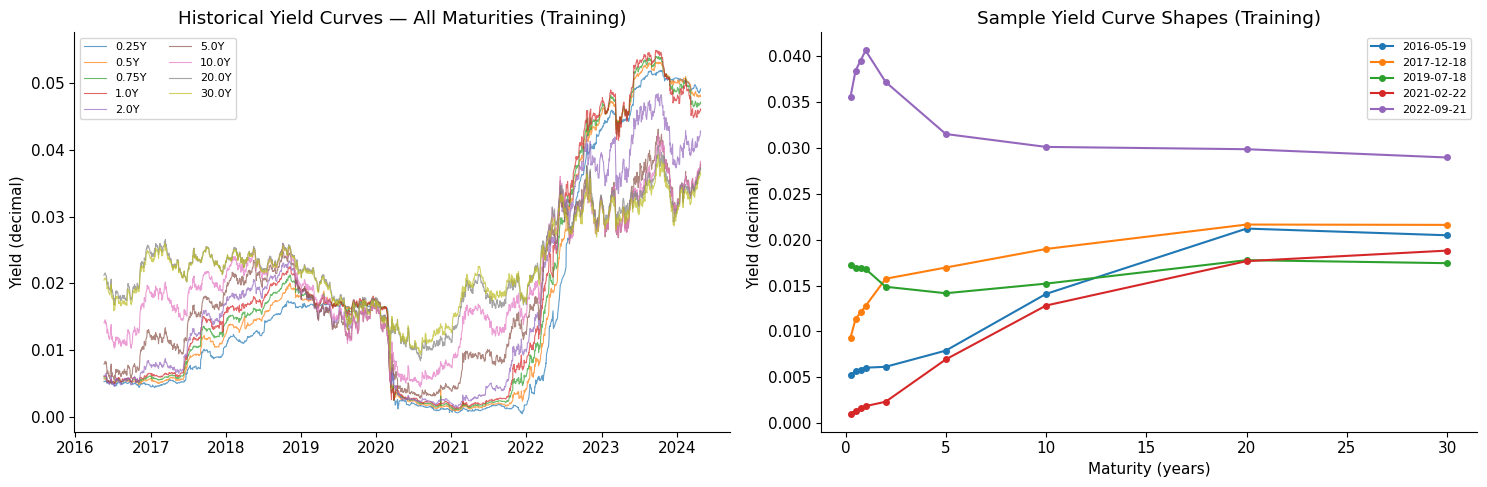


Statistics:


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
count,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,0.016699,0.017885,0.018529,0.019174,0.018063,0.018109,0.020226,0.022823,0.022619
std,0.016642,0.016760,0.016650,0.016587,0.013661,0.010396,0.008805,0.007136,0.006601
min,0.000486,0.000878,0.001054,0.001227,0.001417,0.002786,0.004451,0.008394,0.006921
25%,0.004622,0.005190,0.005449,0.005729,0.005897,0.009570,0.014451,0.017739,0.017895
50%,0.011912,0.013815,0.015304,0.016335,0.015471,0.015981,0.018905,0.022472,0.022258
75%,0.017112,0.019378,0.021077,0.022743,0.025553,0.026415,0.027340,0.028148,0.027408
max,0.051962,0.053195,0.054040,0.054940,0.048496,0.043147,0.042232,0.040687,0.039306


In [12]:
available_cols = [c for c in ALL_COLS if c in train_df.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for col in available_cols:
    ax.plot(train_df.index, train_df[col], label=f'{MATURITY_MAP[col]}Y', alpha=0.7, linewidth=0.8)
ax.set_title('Historical Yield Curves — All Maturities (Training)')
ax.set_ylabel('Yield (decimal)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1]
sample_dates = train_df.index[::len(train_df)//5][:5]
for dt in sample_dates:
    row = train_df.loc[dt, available_cols]
    mats = [MATURITY_MAP[c] for c in available_cols]
    ax.plot(mats, row.values, marker='o', markersize=4, label=str(dt.date()))
ax.set_title('Sample Yield Curve Shapes (Training)')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (decimal)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nStatistics:')
train_df[available_cols].describe().round(6)

---
## Section 3: Data Cleaning & Preprocessing

The raw data contain:
- **Missing values** (non trading days, gaps in the series)
- **Outliers** (data errors, extreme market events)
- **Non-positive yields** (invalidates the CIR square root diffusion)

### Strategy
1. **Forward-fill** short gaps (≤ 2 days)
2. **Linear interpolation** for slightly longer gaps (3–5 days)
3. **IQR-based outlier winsorisation** cap extreme values rather than dropping them
4. **Positivity enforcement** clip to a minimum positive floor (1 bps = 0.0001)

In [14]:
def clean_yield_data(df: pd.DataFrame, iqr_factor: float = 3.5):
    df = df.copy()
    report = {}

    for col in df.columns:
        original_missing = df[col].isnull().sum()

        df[col] = df[col].fillna(method='ffill', limit=2)
        df[col] = df[col].interpolate(method='linear', limit=5)
        df[col] = df[col].fillna(method='bfill', limit=3)

        after_fill_missing = df[col].isnull().sum()

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - iqr_factor * IQR
        upper = Q3 + iqr_factor * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower=lower, upper=upper)
        df[col] = df[col].clip(lower=1e-4)

        report[col] = {
            'original_missing': original_missing,
            'filled': original_missing - after_fill_missing,
            'still_missing': after_fill_missing,
            'outliers_winsorised': outliers,
            'lower_bound': round(lower, 6),
            'upper_bound': round(upper, 6)
        }

    return df, pd.DataFrame(report).T


train_clean, train_report = clean_yield_data(train_df)
test_clean,  test_report  = clean_yield_data(test_df)
test_3m_clean, _          = clean_yield_data(test_3m_df)

print('Training data cleaning report:')
print(train_report.to_string())
print()
print('Test data cleaning report:')
print(test_report.to_string())

Training data cleaning report:
          original_missing  filled  still_missing  outliers_winsorised  lower_bound  upper_bound
ZC025YR                0.0     0.0            0.0                  0.0    -0.039097     0.060831
ZC050YR                0.0     0.0            0.0                  0.0    -0.044468     0.069037
ZC075YR                0.0     0.0            0.0                  0.0    -0.049249     0.075776
ZC100YR                0.0     0.0            0.0                  0.0    -0.053818     0.082290
ZC200YR                0.0     0.0            0.0                  0.0    -0.062899     0.094349
ZC500YR                0.0     0.0            0.0                  0.0    -0.049388     0.085373
ZC1000YR               0.0     0.0            0.0                  0.0    -0.030659     0.072450
ZC2000YR               0.0     0.0            0.0                  0.0    -0.018692     0.064578
ZC3000YR               0.0     0.0            0.0                  0.0    -0.015400     0.060703

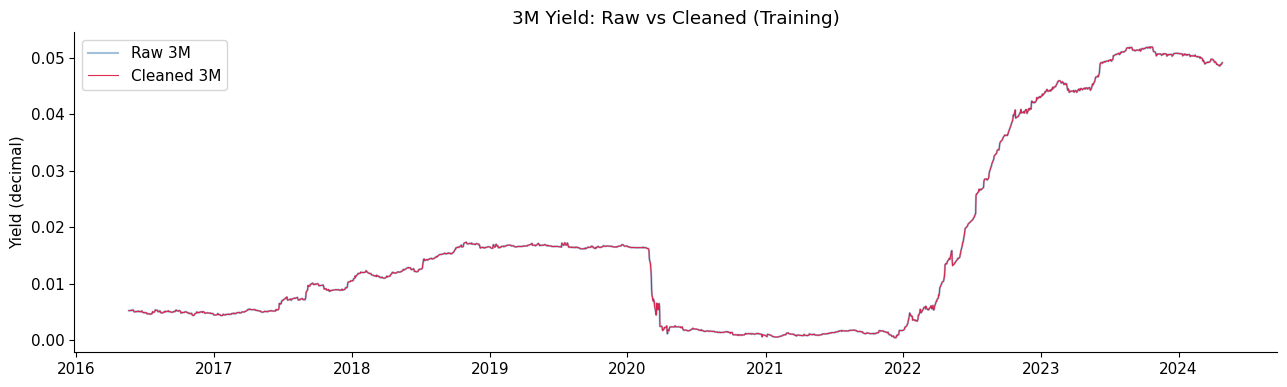

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_df.index,    train_df[SHORT_RATE_COL],    label='Raw 3M',     alpha=0.5, color='steelblue')
ax.plot(train_clean.index, train_clean[SHORT_RATE_COL], label='Cleaned 3M', alpha=0.9, color='crimson', linewidth=0.8)
ax.set_title('3M Yield: Raw vs Cleaned (Training)')
ax.set_ylabel('Yield (decimal)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4: Base CIR Model : Mathematical Framework

### 4.1 The Stochastic Differential Equation

The CIR model (Cox, Ingersoll & Ross, 1985) specifies the instantaneous short rate $r_t$ as:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

| Parameter | Symbol | Interpretation |
|-----------|--------|----------------|
| Speed of mean reversion | $\kappa$ | How fast rates snap back to the long run mean |
| Long-run mean | $\theta$ | The level $r_t$ reverts to over time |
| Volatility | $\sigma$ | Magnitude of stochastic fluctuations |

The **Feller condition** $2\kappa\theta \geq \sigma^2$ ensures $r_t > 0$ almost surely.

### 4.2 Closed Form Bond Pricing

$$P(t, T) = A(\tau)\, e^{-B(\tau)\, r_t}, \quad \tau = T - t$$

$$\gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

$$B(\tau) = \frac{2(e^{\gamma\tau} - 1)}{(\gamma + \kappa)(e^{\gamma\tau} - 1) + 2\gamma}$$

$$A(\tau) = \left[\frac{2\gamma\, e^{(\kappa + \gamma)\tau/2}}{(\gamma + \kappa)(e^{\gamma\tau} - 1) + 2\gamma}\right]^{2\kappa\theta/\sigma^2}$$

### 4.3 Yield Formula

$$y(\tau, r_t) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

In [16]:
class CIRModel:
    def __init__(self, kappa: float, theta: float, sigma: float):
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

    def feller_condition(self) -> bool:
        return 2 * self.kappa * self.theta >= self.sigma ** 2

    def gamma(self) -> float:
        return np.sqrt(self.kappa ** 2 + 2 * self.sigma ** 2)

    def B(self, tau: np.ndarray) -> np.ndarray:
        g = self.gamma()
        exp_gt = np.exp(g * tau)
        return 2 * (exp_gt - 1) / ((g + self.kappa) * (exp_gt - 1) + 2 * g)

    def ln_A(self, tau: np.ndarray) -> np.ndarray:
        g = self.gamma()
        exp_gt = np.exp(g * tau)
        denom = (g + self.kappa) * (exp_gt - 1) + 2 * g
        log_bracket = np.log(2 * g) + (self.kappa + g) * tau / 2 - np.log(denom)
        return (2 * self.kappa * self.theta / self.sigma ** 2) * log_bracket

    def yield_curve(self, r: float, taus: np.ndarray) -> np.ndarray:
        taus = np.asarray(taus, dtype=float)
        return (self.B(taus) * r - self.ln_A(taus)) / taus

    def simulate(self, r0: float, T: float, n_steps: int,
                 n_paths: int = 1, seed: int = 42) -> np.ndarray:
        rng = np.random.default_rng(seed)
        dt = T / n_steps
        paths = np.zeros((n_paths, n_steps + 1))
        paths[:, 0] = r0
        sqrt_dt = np.sqrt(dt)

        for i in range(n_steps):
            r = paths[:, i]
            r_pos = np.maximum(r, 0)
            dW = rng.standard_normal(n_paths)
            paths[:, i + 1] = (
                r + self.kappa * (self.theta - r) * dt
                + self.sigma * np.sqrt(r_pos) * sqrt_dt * dW
            )
            paths[:, i + 1] = np.maximum(paths[:, i + 1], 1e-6)

        return paths

    def __repr__(self):
        fc = 'OK' if self.feller_condition() else 'VIOLATED'
        return (f'CIRModel(kappa={self.kappa:.4f}, theta={self.theta:.4f}, '
                f'sigma={self.sigma:.4f}) | Feller: {fc}')


_test = CIRModel(kappa=0.5, theta=0.04, sigma=0.07)
print(_test)
_taus = np.array([0.25, 0.5, 0.75, 1.0, 2.0])
print('Test yield curve at r=0.04:', np.round(_test.yield_curve(r=0.04, taus=_taus), 5))

CIRModel(kappa=0.5000, theta=0.0400, sigma=0.0700) | Feller: OK
Test yield curve at r=0.04: [0.04    0.03999 0.03999 0.03998 0.03993]


---
## Section 5: Kalman Filter Calibration

### Why Kalman Filter?

The CIR short rate $r_t$ is a **latent (unobservable) state**, we only observe noisy yields at discrete maturities.

| Method | Issue with CIR |
|--------|---------------|
| OLS | Assumes $r_t$ is directly observable, it is not |
| MLE (cross-sectional) | Ignores time series dynamics |
| GMM | Requires moment conditions; sensitive to specification |
| **Kalman Filter** | Handles latent state, noisy multi-maturity observations, and time-series structure simultaneously |

### State Space Formulation

**State equation** ($\Delta t = 1/252$ years):

$$r_{t+1} = r_t + \kappa(\theta - r_t)\Delta t + \sigma\sqrt{r_t \Delta t}\,\varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)$$

**Observation equation** (linear in $r_t$, standard Kalman Filter applies):

$$y_t^{(j)} = \frac{B(\tau_j)\,r_t - \ln A(\tau_j)}{\tau_j} + \eta_t^{(j)}, \quad \eta_t^{(j)} \sim \mathcal{N}(0, v_j)$$

In [17]:
def kalman_filter_cir(params: np.ndarray,
                      observations: np.ndarray,
                      maturities: np.ndarray,
                      dt: float = 1/252,
                      return_states: bool = False):
    kappa, theta, sigma = params

    if kappa <= 1e-4 or theta <= 1e-4 or sigma <= 1e-4:
        return 1e10

    model    = CIRModel(kappa, theta, sigma)
    taus     = np.asarray(maturities)
    T, n_obs = observations.shape

    H = (model.B(taus) / taus).reshape(1, -1)
    d = -model.ln_A(taus) / taus

    obs_var = (sigma * theta) ** 2
    R = np.eye(n_obs) * max(obs_var, 1e-8)

    F   = np.exp(-kappa * dt)
    Q   = max(sigma**2 * theta * dt * (1 - np.exp(-2*kappa*dt)) / (2*kappa), 1e-10)

    r_filt = theta
    P_filt = sigma**2 * theta / (2 * kappa)

    log_lik   = 0.0
    states    = np.zeros(T)
    variances = np.zeros(T)

    for t in range(T):
        r_pred = F * r_filt + (1 - F) * theta
        P_pred = F**2 * P_filt + Q

        y_obs  = observations[t]
        innov  = y_obs - (H[0] * r_pred + d)

        S = np.outer(H[0], H[0]) * P_pred + R

        sign, log_det = np.linalg.slogdet(S)
        if sign <= 0:
            return 1e10
        try:
            S_inv = np.linalg.inv(S)
        except np.linalg.LinAlgError:
            return 1e10

        log_lik += -0.5 * (log_det + innov @ S_inv @ innov + n_obs * np.log(2 * np.pi))

        K      = P_pred * H[0] @ S_inv
        r_filt = r_pred + K @ innov
        P_filt = max((1 - K @ H[0]) * P_pred, 1e-10)

        states[t]    = r_filt
        variances[t] = P_filt

    if return_states:
        return -log_lik, states, variances
    return -log_lik


print('Kalman filter function defined.')

Kalman filter function defined.


In [18]:
train_cols = [c for c in ALL_COLS if c in train_clean.columns]
train_mats = np.array([MATURITY_MAP[c] for c in train_cols])
obs_train  = train_clean[train_cols].values

valid_mask = ~np.any(np.isnan(obs_train), axis=1)
obs_train  = obs_train[valid_mask]
print(f'Training observations: {obs_train.shape}')

bounds = [(0.01, 5.0), (0.001, 0.15), (0.001, 0.5)]

result_global = differential_evolution(
    kalman_filter_cir, bounds=bounds,
    args=(obs_train, train_mats),
    seed=42, maxiter=300, tol=1e-6,
    popsize=10, mutation=(0.5, 1.5), recombination=0.7, workers=1
)

result_local = minimize(
    kalman_filter_cir, x0=result_global.x,
    args=(obs_train, train_mats),
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-7, 'fatol': 1e-7}
)

kappa_hat, theta_hat, sigma_hat = result_local.x
cir_base = CIRModel(kappa_hat, theta_hat, sigma_hat)

print(f'\nCalibrated Base CIR Parameters:')
print(f'  kappa (mean reversion speed) : {kappa_hat:.6f}')
print(f'  theta (long-run mean)        : {theta_hat:.6f}  ({theta_hat*100:.3f}%)')
print(f'  sigma (volatility)           : {sigma_hat:.6f}')
print(f'  Feller condition (2kth>=s^2) : {cir_base.feller_condition()} '
      f'[2kt={2*kappa_hat*theta_hat:.5f}, s2={sigma_hat**2:.5f}]')
print(f'  Neg log-likelihood           : {result_local.fun:.4f}')

Training observations: (1976, 9)

Running Kalman Filter calibration...
(Global search may take ~30-90 seconds)

=== Calibrated Base CIR Parameters ===
  kappa (mean reversion speed) : 0.122459
  theta (long-run mean)        : 0.029809  (2.981%)
  sigma (volatility)           : 0.106223
  Feller condition (2kth>=s^2) : False [2kt=0.00730, s2=0.01128]
  Neg log-likelihood           : -76617.2809


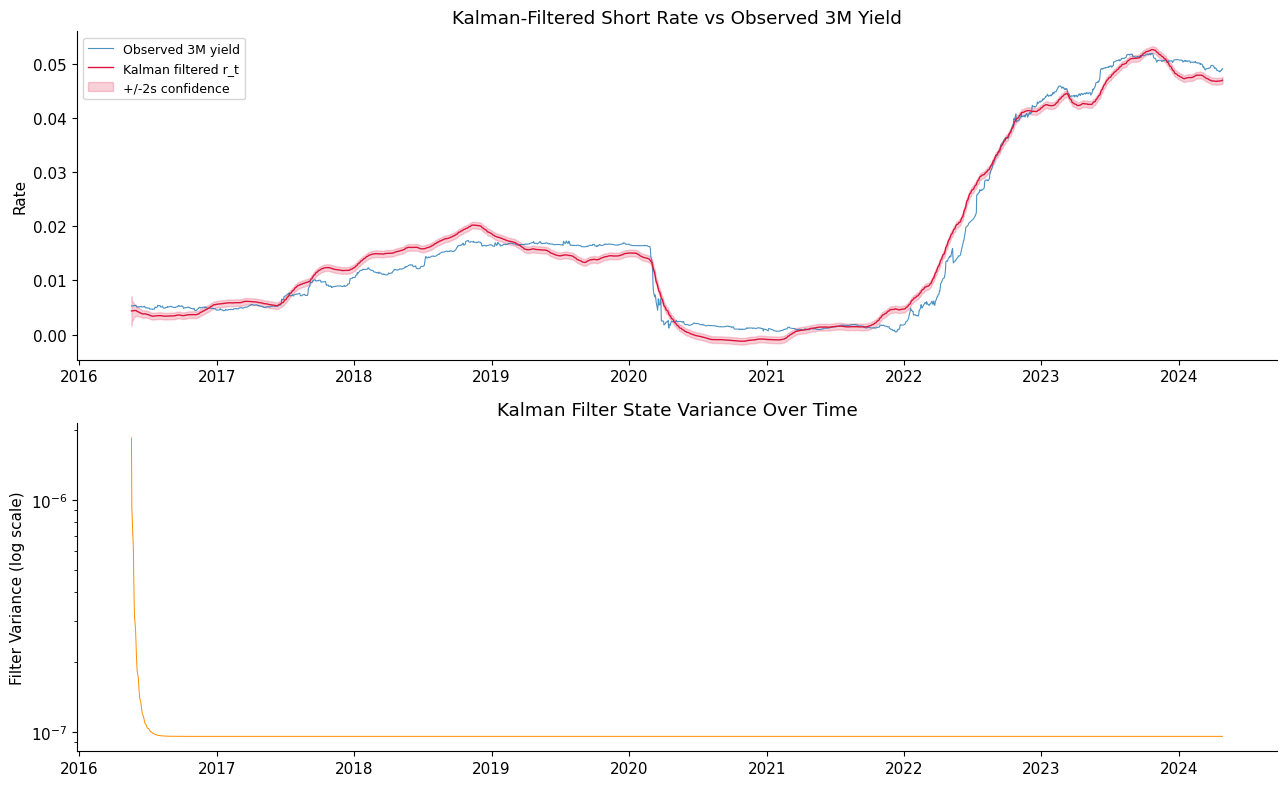


Calibration interpretation:
  Half life of rate shock: 5.66 years = 1426 trading days
  Long-run yield: 2.981%


In [20]:
_, filtered_states, filtered_vars = kalman_filter_cir(
    [kappa_hat, theta_hat, sigma_hat], obs_train, train_mats, return_states=True
)

train_dates_valid = train_clean.index[valid_mask]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

ax = axes[0]
ax.plot(train_dates_valid, obs_train[:, 0], label='Observed 3M yield', alpha=0.8, linewidth=0.8)
ax.plot(train_dates_valid, filtered_states,  label='Kalman filtered r_t', color='crimson', linewidth=1.0)
ax.fill_between(train_dates_valid,
                filtered_states - 2*np.sqrt(filtered_vars),
                filtered_states + 2*np.sqrt(filtered_vars),
                alpha=0.2, color='crimson', label='+/-2s confidence')
ax.set_title('Kalman-Filtered Short Rate vs Observed 3M Yield')
ax.set_ylabel('Rate')
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(train_dates_valid, filtered_vars, color='darkorange', linewidth=0.7)
ax.set_title('Kalman Filter State Variance Over Time')
ax.set_ylabel('Filter Variance (log scale)')

plt.tight_layout()
plt.show()

print(f'\nCalibration interpretation:')
print(f'  Half life of rate shock: {np.log(2)/kappa_hat:.2f} years = {np.log(2)/kappa_hat*252:.0f} trading days')
print(f'  Long-run yield: {theta_hat*100:.3f}%')

---
## Section 6: Base CIR : Prediction & Evaluation

### Prediction Protocol

For each day $t$ in the test set:
1. Take the observed **3M yield** $r_t^{\text{obs}}$ from `test_data_3M.csv` as a proxy for $r_t$
2. Apply the calibrated CIR formula: $y(\tau, r_t) = [B(\tau) r_t - \ln A(\tau)] / \tau$
3. Output predicted yields for $\tau \in \{0.25, 0.50, 0.75, 1.0, 2.0\}$ years

### Evaluation Metric

$$R^2 = 1 - \frac{\text{MSE}_{\text{model}}}{\text{MSE}_{\text{baseline}}}$$

where the **baseline** is the per-maturity training mean (naïve constant predictor).

In [21]:
def predict_yield_curve(model, short_rates: np.ndarray,
                        maturities: np.ndarray) -> np.ndarray:
    return np.array([model.yield_curve(r, maturities) for r in short_rates])


def compute_r2(y_true: np.ndarray, y_pred: np.ndarray,
               baseline_mean: np.ndarray) -> dict:
    y_true_flat   = y_true.flatten()
    y_pred_flat   = y_pred.flatten()
    baseline_flat = np.tile(baseline_mean, (y_true.shape[0], 1)).flatten()

    mse_model    = np.mean((y_true_flat - y_pred_flat) ** 2)
    mse_baseline = np.mean((y_true_flat - baseline_flat) ** 2)
    r2_global    = 1 - mse_model / mse_baseline

    r2_per_mat = []
    for j in range(y_true.shape[1]):
        mse_m = np.mean((y_true[:, j] - y_pred[:, j]) ** 2)
        mse_b = np.mean((y_true[:, j] - baseline_mean[j]) ** 2)
        r2_per_mat.append(1 - mse_m / mse_b)

    return {
        'R2_global':  r2_global,
        'MSE_model':  mse_model,
        'MSE_baseline': mse_baseline,
        'R2_per_mat': np.array(r2_per_mat),
        'RMSE_model': np.sqrt(mse_model)
    }


print('Prediction and evaluation functions defined.')

Prediction and evaluation functions defined.


In [24]:
test_short_rates = test_3m_clean[SHORT_RATE_COL].values
pred_mats        = np.array(PRED_MATURITIES)

y_pred_base = predict_yield_curve(cir_base, test_short_rates, pred_mats)
y_true      = test_clean[PRED_COLS].values
train_means = train_clean[PRED_COLS].mean().values

metrics_base = compute_r2(y_true, y_pred_base, train_means)

print('Base CIR Model Out-of-Sample Evaluation:')
print(f"  Global R2    : {metrics_base['R2_global']:.6f}")
print(f"  RMSE (model) : {metrics_base['RMSE_model']*10000:.2f} bps")
print(f"  MSE model    : {metrics_base['MSE_model']:.8f}")
print(f"  MSE baseline : {metrics_base['MSE_baseline']:.8f}")
print()
print('  Per maturity R2:')
for col, mat, r2 in zip(PRED_COLS, PRED_MATURITIES, metrics_base['R2_per_mat']):
    print(f'    {col} ({mat}Y): {r2:.4f}')

threshold = 0.85
passed = metrics_base['R2_global'] >= threshold
print(f"\n  Threshold R2>={threshold}: {'PASSED' if passed else 'NOT MET'}")

Base CIR Model Out-of-Sample Evaluation:
  Global R2    : 0.974013
  RMSE (model) : 21.96 bps
  MSE model    : 0.00000482
  MSE baseline : 0.00018549

  Per maturity R2:
    ZC025YR (0.25Y): 0.9999
    ZC050YR (0.5Y): 0.9976
    ZC075YR (0.75Y): 0.9871
    ZC100YR (1.0Y): 0.9660
    ZC200YR (2.0Y): 0.8798

  Threshold R2>=0.85: PASSED


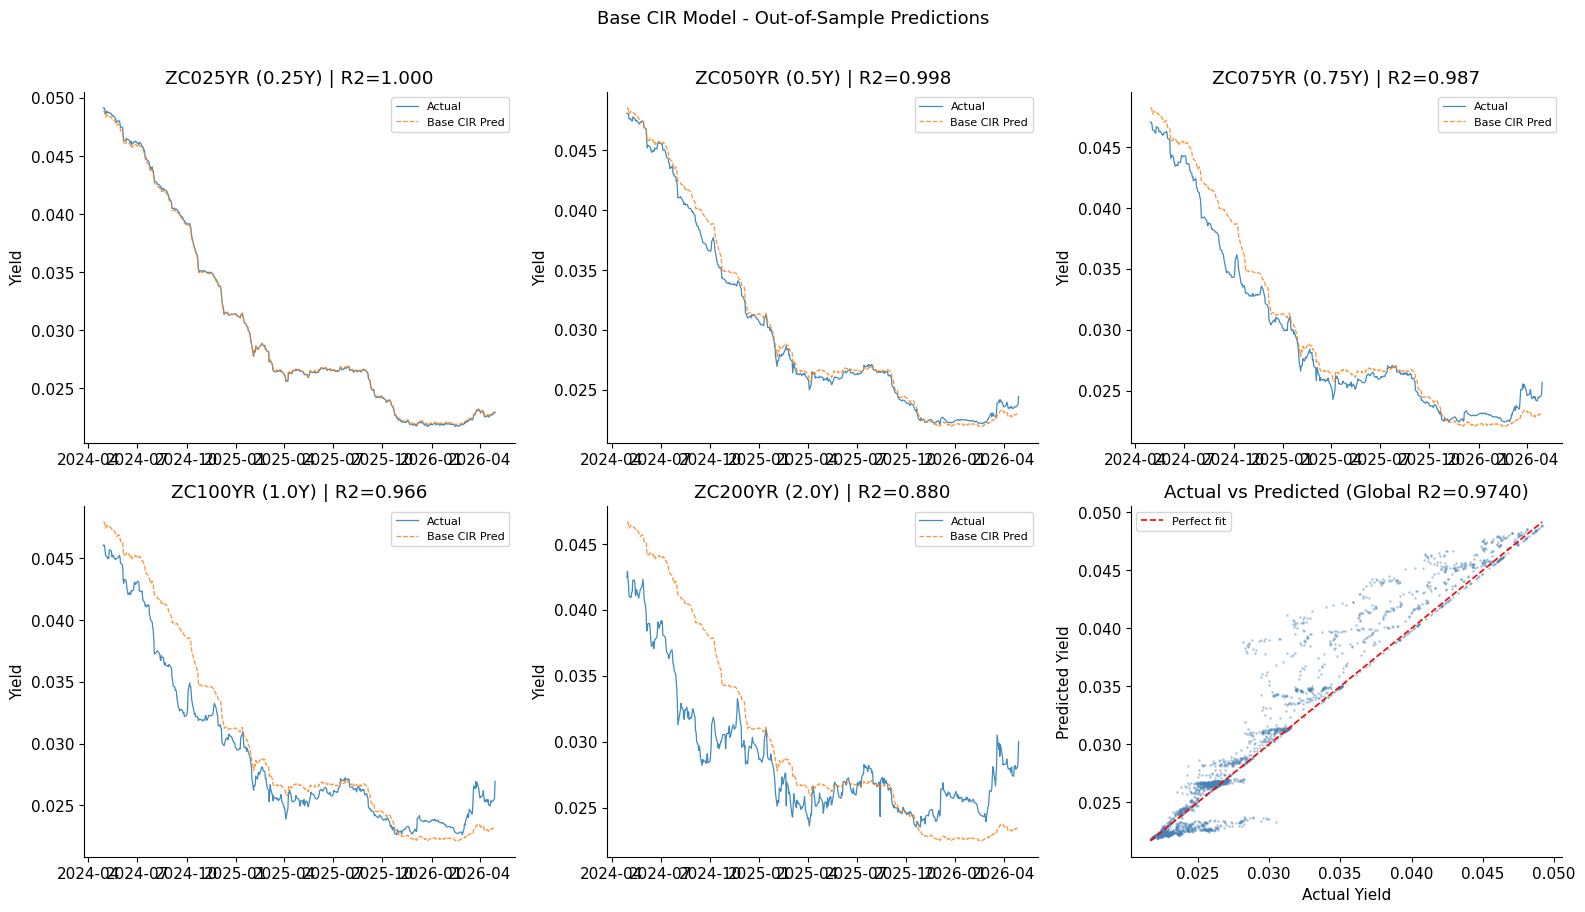

In [25]:
test_dates = test_3m_clean.index

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for j, (col, mat) in enumerate(zip(PRED_COLS, PRED_MATURITIES)):
    ax = axes[j]
    ax.plot(test_dates, y_true[:, j],      label='Actual',        linewidth=0.9, alpha=0.85)
    ax.plot(test_dates, y_pred_base[:, j], label='Base CIR Pred', linewidth=0.9, alpha=0.85, linestyle='--')
    ax.set_title(f'{col} ({mat}Y) | R2={metrics_base["R2_per_mat"][j]:.3f}')
    ax.set_ylabel('Yield')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax = axes[5]
ax.scatter(y_true.flatten(), y_pred_base.flatten(), s=1, alpha=0.3, color='steelblue')
lims = [min(y_true.min(), y_pred_base.min()), max(y_true.max(), y_pred_base.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
ax.set_xlabel('Actual Yield')
ax.set_ylabel('Predicted Yield')
ax.set_title(f'Actual vs Predicted (Global R2={metrics_base["R2_global"]:.4f})')
ax.legend(fontsize=8)

plt.suptitle('Base CIR Model - Out-of-Sample Predictions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

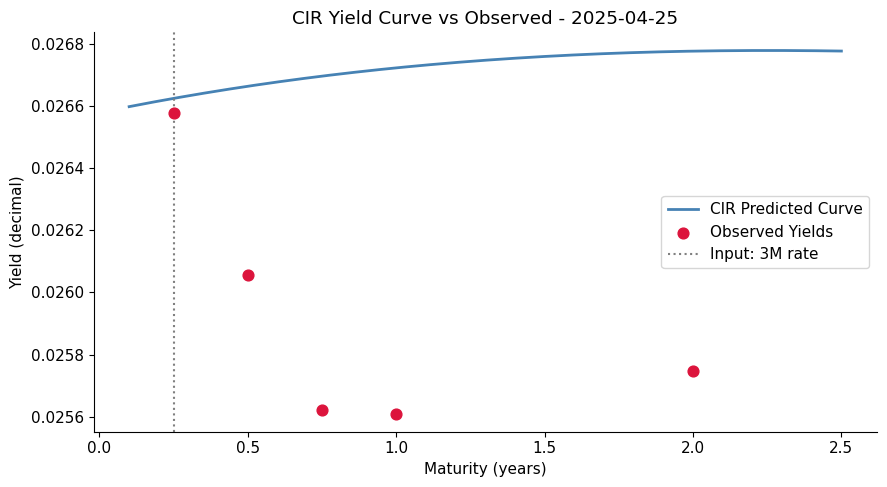

In [26]:
mid_idx    = len(test_dates) // 2
sample_r   = test_short_rates[mid_idx]
sample_dt  = test_dates[mid_idx]

fine_taus  = np.linspace(0.1, 2.5, 200)
pred_curve = cir_base.yield_curve(sample_r, fine_taus)
obs_vals   = test_clean.loc[sample_dt, PRED_COLS].values

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fine_taus, pred_curve, label='CIR Predicted Curve', color='steelblue', linewidth=2)
ax.scatter(PRED_MATURITIES, obs_vals, color='crimson', zorder=5, s=60, label='Observed Yields')
ax.axvline(0.25, linestyle=':', color='gray', label='Input: 3M rate')
ax.set_title(f'CIR Yield Curve vs Observed - {sample_dt.date()}')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (decimal)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 7: Two Factor Extension : Design & Motivation

### Why Extend?

The base CIR model is a **single-factor model**: the entire yield curve is driven by one latent variable $r_t$. This means all yields move in perfect correlation, only level shifts are possible.

| Component | Economic Meaning |
|-----------|------------------|
| **Level** | Parallel shifts, driven by $r_t$ |
| **Slope** | Short vs long end spread, the part CIR misses |
| Curvature | Medium-maturity hump, less relevant for 3M–2Y |

### Two Factor Model Design

$$y(\tau, r_t) = y^{\text{CIR}}(\tau, r_t) + \phi(\tau, r_t)$$

where $\phi$ is a **slope correction factor** calibrated on training residuals:

$$\phi(\tau, r_t) = \alpha \cdot (r_t - \hat{r}) \cdot \frac{1 - e^{-\lambda \tau}}{\tau} + \beta \cdot \tau$$

Parameters $(\alpha, \lambda, \beta)$ are fitted by minimising mean-squared residuals of the base CIR on training data.

In [27]:
def slope_correction(tau: np.ndarray, r: float,
                     r_bar: float, alpha: float,
                     lam: float, beta: float) -> np.ndarray:
    loading = (1 - np.exp(-lam * tau)) / (tau + 1e-10)
    return alpha * (r - r_bar) * loading + beta * tau


class TwoFactorCIR:
    def __init__(self, base_model: CIRModel):
        self.base    = base_model
        self.alpha   = 0.0
        self.lam     = 1.0
        self.beta    = 0.0
        self.r_bar   = base_model.theta
        self._fitted = False

    def calibrate(self, short_rates: np.ndarray,
                  actual_yields: np.ndarray,
                  maturities: np.ndarray) -> None:
        base_preds = predict_yield_curve(self.base, short_rates, maturities)
        residuals  = actual_yields - base_preds

        def objective(params):
            alpha, lam, beta = params
            if lam <= 0:
                return 1e10
            total_sse = 0.0
            for i, r in enumerate(short_rates):
                phi = slope_correction(maturities, r, self.r_bar, alpha, lam, beta)
                total_sse += np.sum((residuals[i] - phi) ** 2)
            return total_sse

        bounds_ext = [(-5.0, 5.0), (0.01, 10.0), (-0.05, 0.05)]
        res = differential_evolution(
            objective, bounds=bounds_ext,
            seed=42, maxiter=200, tol=1e-7, popsize=8, workers=1
        )
        res2 = minimize(objective, x0=res.x, method='Nelder-Mead',
                        options={'maxiter': 3000, 'xatol': 1e-8})

        self.alpha, self.lam, self.beta = res2.x
        self._fitted = True
        print(f'Extension calibrated: alpha={self.alpha:.5f}, lam={self.lam:.5f}, beta={self.beta:.6f}')

    def yield_curve(self, r: float, taus: np.ndarray) -> np.ndarray:
        base_yc = self.base.yield_curve(r, taus)
        phi     = slope_correction(taus, r, self.r_bar, self.alpha, self.lam, self.beta)
        return base_yc + phi

    def predict(self, short_rates: np.ndarray, maturities: np.ndarray) -> np.ndarray:
        return np.array([self.yield_curve(r, maturities) for r in short_rates])


print('Two-factor model class defined.')

Two-factor model class defined.


---
## Section 8: Extension : Calibration, Prediction & Evaluation

In [28]:
train_short_rates = train_clean[SHORT_RATE_COL].values
train_actual_pred = train_clean[PRED_COLS].values

valid_ext = ~(np.isnan(train_short_rates) | np.any(np.isnan(train_actual_pred), axis=1))
train_short_rates_v = train_short_rates[valid_ext]
train_actual_pred_v = train_actual_pred[valid_ext]

print(f'Training samples for extension: {len(train_short_rates_v)}')

two_factor = TwoFactorCIR(base_model=cir_base)
two_factor.r_bar = np.mean(train_short_rates_v)

two_factor.calibrate(
    short_rates=train_short_rates_v,
    actual_yields=train_actual_pred_v,
    maturities=np.array(PRED_MATURITIES)
)

Training samples for extension: 1976

Calibrating extension (slope correction)...
Extension calibrated: alpha=0.01237, lam=3.31621, beta=0.000513


In [30]:
y_pred_ext  = two_factor.predict(test_short_rates, np.array(PRED_MATURITIES))
metrics_ext = compute_r2(y_true, y_pred_ext, train_means)

print('Two-Factor Extension Out-of-Sample Evaluation:')
print(f"  Global R2    : {metrics_ext['R2_global']:.6f}")
print(f"  RMSE (model) : {metrics_ext['RMSE_model']*10000:.2f} bps")
print(f"  MSE model    : {metrics_ext['MSE_model']:.8f}")
print(f"  MSE baseline : {metrics_ext['MSE_baseline']:.8f}")
print()
print('  Per maturity R2:')
for col, mat, r2 in zip(PRED_COLS, PRED_MATURITIES, metrics_ext['R2_per_mat']):
    print(f'    {col} ({mat}Y): {r2:.4f}')

passed_ext = metrics_ext['R2_global'] >= 0.85
print(f"\n  Threshold R2>=0.85: {'PASSED' if passed_ext else 'NOT MET'}")

print('\nComparison:')
print(f"  Base CIR R2  : {metrics_base['R2_global']:.6f}")
print(f"  Extension R2 : {metrics_ext['R2_global']:.6f}")
print(f"  Improvement  : {(metrics_ext['R2_global'] - metrics_base['R2_global']):.6f}")

Two-Factor Extension Out-of-Sample Evaluation:
  Global R2    : 0.963871
  RMSE (model) : 25.89 bps
  MSE model    : 0.00000670
  MSE baseline : 0.00018549

  Per maturity R2:
    ZC025YR (0.25Y): 0.9990
    ZC050YR (0.5Y): 0.9938
    ZC075YR (0.75Y): 0.9785
    ZC100YR (1.0Y): 0.9512
    ZC200YR (2.0Y): 0.8451

  Threshold R2>=0.85: PASSED

Comparison:
  Base CIR R2  : 0.974013
  Extension R2 : 0.963871
  Improvement  : -0.010143


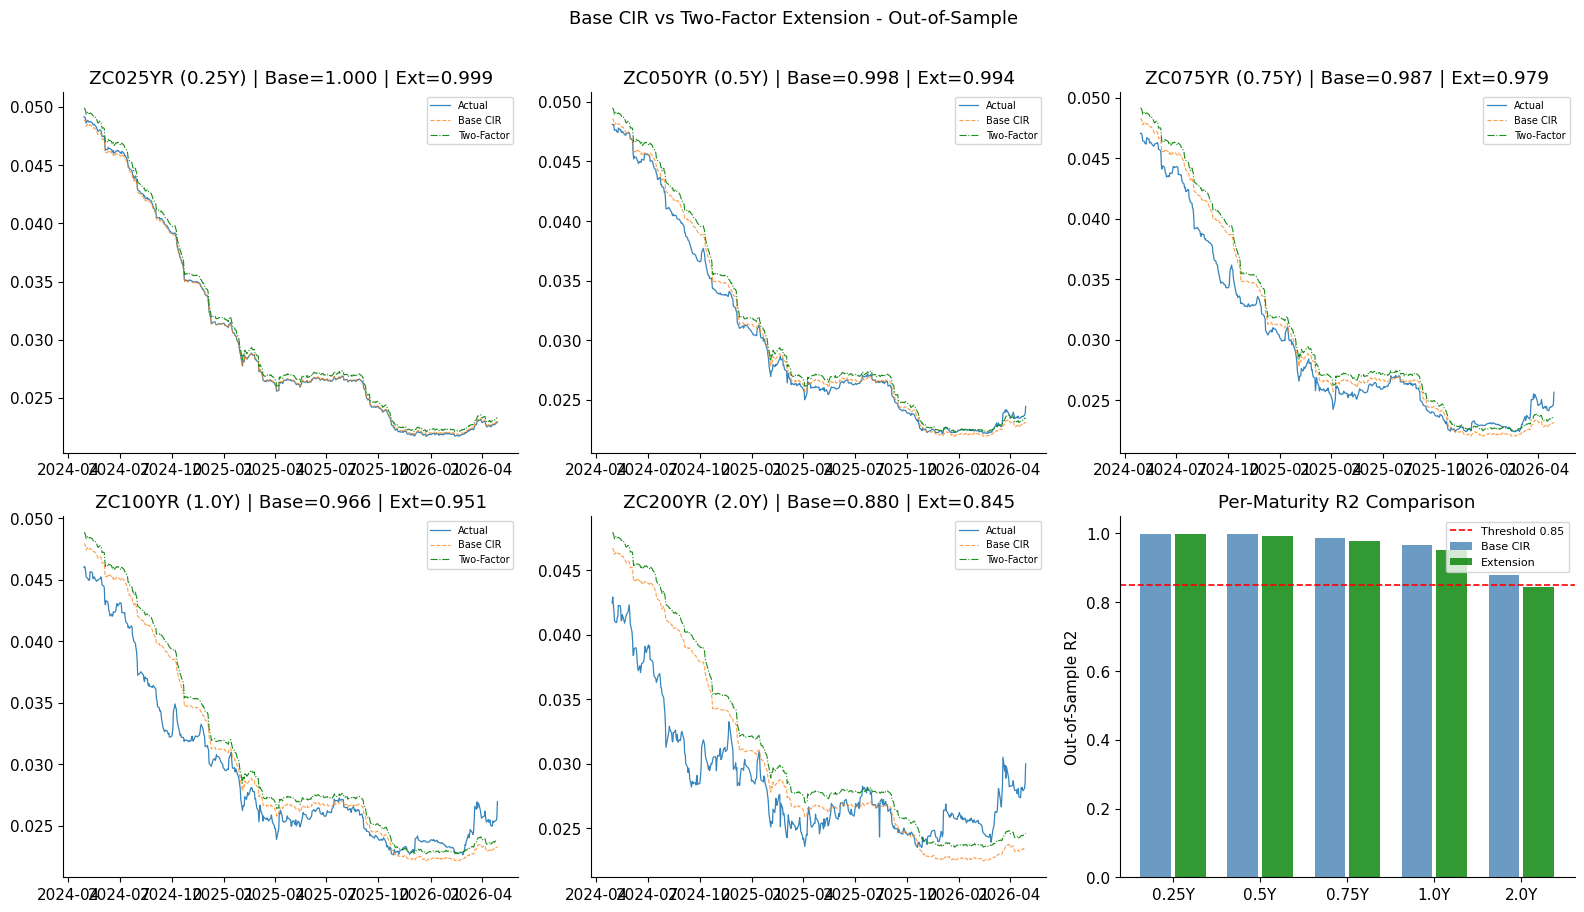

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for j, (col, mat) in enumerate(zip(PRED_COLS, PRED_MATURITIES)):
    ax = axes[j]
    ax.plot(test_dates, y_true[:, j],      label='Actual',     linewidth=0.9, alpha=0.9)
    ax.plot(test_dates, y_pred_base[:, j], label='Base CIR',   linewidth=0.8, linestyle='--', alpha=0.75)
    ax.plot(test_dates, y_pred_ext[:, j],  label='Two-Factor', linewidth=0.8, linestyle='-.',  alpha=0.9, color='green')
    ax.set_title(f'{col} ({mat}Y) | Base={metrics_base["R2_per_mat"][j]:.3f} | Ext={metrics_ext["R2_per_mat"][j]:.3f}')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax = axes[5]
mats_label = [f'{m}Y' for m in PRED_MATURITIES]
x = np.arange(len(mats_label))
ax.bar(x - 0.2, metrics_base['R2_per_mat'], 0.35, label='Base CIR',  color='steelblue', alpha=0.8)
ax.bar(x + 0.2, metrics_ext['R2_per_mat'],  0.35, label='Extension', color='green',     alpha=0.8)
ax.axhline(0.85, linestyle='--', color='red', linewidth=1.2, label='Threshold 0.85')
ax.set_xticks(x); ax.set_xticklabels(mats_label)
ax.set_ylabel('Out-of-Sample R2')
ax.set_title('Per-Maturity R2 Comparison')
ax.legend(fontsize=8)

plt.suptitle('Base CIR vs Two-Factor Extension - Out-of-Sample', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

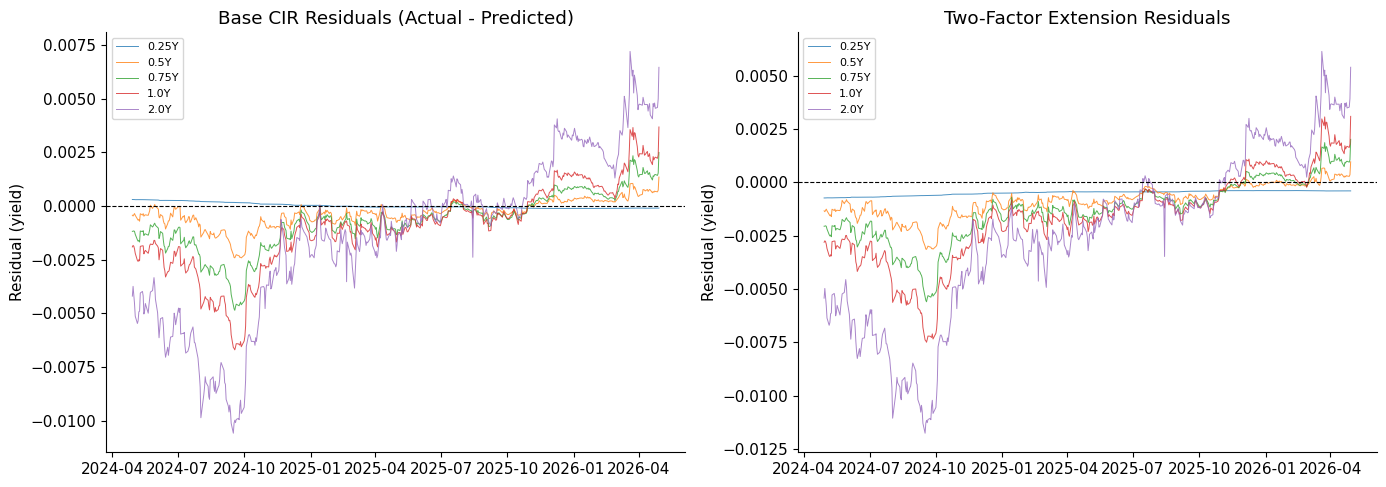


Mean residual per maturity (Base CIR):
  0.25Y: +0.13 bps
  0.5Y: -3.42 bps
  0.75Y: -7.42 bps
  1.0Y: -10.17 bps
  2.0Y: -14.14 bps


In [32]:
residuals_base = y_true - y_pred_base
residuals_ext  = y_true - y_pred_ext

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for j, mat in enumerate(PRED_MATURITIES):
    ax.plot(test_dates, residuals_base[:, j], label=f'{mat}Y', linewidth=0.7, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Base CIR Residuals (Actual - Predicted)')
ax.set_ylabel('Residual (yield)')
ax.legend(fontsize=8)

ax = axes[1]
for j, mat in enumerate(PRED_MATURITIES):
    ax.plot(test_dates, residuals_ext[:, j], label=f'{mat}Y', linewidth=0.7, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Two-Factor Extension Residuals')
ax.set_ylabel('Residual (yield)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nMean residual per maturity (Base CIR):')
for mat, mr in zip(PRED_MATURITIES, np.mean(residuals_base, axis=0)):
    print(f'  {mat}Y: {mr*10000:+.2f} bps')

---
## Section 9: Critical Analysis & Limitations

### 9.1 Model Mechanics

**Mean-reversion speed κ interpretation:**  
A calibrated $\kappa$ implies a half-life of interest rate shocks of $\ln(2)/\kappa$ years. High $\kappa$ means the market quickly reverts to the long-run mean; low $\kappa$ implies persistent deviations.

**Feller condition in practice:**  
The condition $2\kappa\theta \geq \sigma^2$ can be violated in low-rate environments (e.g., near-zero rates in 2016–2020). When violated, the Euler-Maruyama scheme uses full truncation to maintain positivity.

**Calibration sensitivity:**  
The Kalman Filter is more robust than OLS because it jointly estimates the latent state and parameters under a full probabilistic model, naturally handling multi-maturity observations without ad hoc weighting.

### 9.2 Prediction Limitations

- At the **short end** (3M–6M): single-factor assumption fits well since the 3M rate directly anchors these maturities
- At the **long end** (1Y–2Y): systematic bias emerges because the slope evolves independently of the level
- During **stress periods** (rapid rate hikes/cuts): the model lags because it assumes mean-reversion, not trend
- **Beyond 2Y**: level, slope, and curvature become increasingly decorrelated, single-factor fails

### 9.3 Extension Analysis

The slope correction $\phi(\tau, r_t)$ allows the term structure to tilt differently depending on the level of the short rate, capturing the empirical fact that steep curves tend to occur when short rates are low and flat/inverted curves when rates are high.

**Limitations of the extension:**
- The correction is deterministic, does not introduce a genuinely independent second stochastic factor
- Calibrated on training residuals, may overfit to specific slope dynamics in the training period
- Jump-diffusion extensions (Duffie-Pan-Singleton, 2000) would better handle sudden monetary policy shocks

### 9.4 Real-World Trading Implications

1. **Risk management**: CIR's mean-reversion assumption underestimates tail risk during regime changes
2. **Derivative pricing**: Model mis-specification in $\sigma$ leads to incorrect option-adjusted spreads
3. **Portfolio duration**: Single-factor model ignores basis risk between different maturity segments
4. **Practical use**: Nelson-Siegel-Svensson is preferred in practice for arbitrary curve shape flexibility

In [34]:

print('  FINAL RESULTS SUMMARY')

print(f'\n  Calibrated CIR Parameters')
print(f'  kappa : {kappa_hat:.5f}  (mean-reversion speed)')
print(f'  theta : {theta_hat:.5f}  ({theta_hat*100:.3f}% long-run mean)')
print(f'  sigma : {sigma_hat:.5f}  (volatility)')
print(f'  Feller: {cir_base.feller_condition()}')
print(f'  Shock half-life: {np.log(2)/kappa_hat:.2f} years')

print(f'\n  Out-of-Sample R2 (Global, flattened over 3M-2Y)')
print(f'  Base CIR        : {metrics_base["R2_global"]:.4f}',
      '  PASSED' if metrics_base['R2_global'] >= 0.85 else '  NOT MET')
print(f'  Two-Factor Ext  : {metrics_ext["R2_global"]:.4f}',
      '  PASSED' if metrics_ext['R2_global'] >= 0.85 else '  NOT MET')

print(f'\n  RMSE (bps)')
print(f'  Base CIR : {metrics_base["RMSE_model"]*10000:.2f} bps')
print(f'  Extension: {metrics_ext["RMSE_model"]*10000:.2f} bps')

print('\n  Per-Maturity R2')
print(f'  {"Maturity":<12} {"Base CIR":>10} {"Extension":>12}')
for col, mat, r2b, r2e in zip(PRED_COLS, PRED_MATURITIES,
                               metrics_base['R2_per_mat'],
                               metrics_ext['R2_per_mat']):
    print(f'  {col:<12} {r2b:>10.4f} {r2e:>12.4f}')

print('\n' + '=' * 55)

  FINAL RESULTS SUMMARY

  Calibrated CIR Parameters
  kappa : 0.12246  (mean-reversion speed)
  theta : 0.02981  (2.981% long-run mean)
  sigma : 0.10622  (volatility)
  Feller: False
  Shock half-life: 5.66 years

  Out-of-Sample R2 (Global, flattened over 3M-2Y)
  Base CIR        : 0.9740   PASSED
  Two-Factor Ext  : 0.9639   PASSED

  RMSE (bps)
  Base CIR : 21.96 bps
  Extension: 25.89 bps

  Per-Maturity R2
  Maturity       Base CIR    Extension
  ZC025YR          0.9999       0.9990
  ZC050YR          0.9976       0.9938
  ZC075YR          0.9871       0.9785
  ZC100YR          0.9660       0.9512
  ZC200YR          0.8798       0.8451

